# Voyage Analytics — Destination & Hotel Recommender

A hybrid **content + popularity** recommender. Classic user-item collaborative
filtering doesn't work well here: with only 9 cities in the whole network,
most frequent travellers have already visited every destination, so the
user-item interaction matrix is far too dense/saturated for CF to find
meaningful "similar user" signal.

Instead: match each user's historical hotel price band to the destinations
most popular among similarly-budgeted travellers, recommend cities they
haven't been to yet, and fall back to "worth revisiting" (their least-visited
cities) for users who've already covered the whole map.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_prep import load_raw, build_recommender_tables
from recommender import build_recommender_artifacts, recommend_for_user

sns.set_style('whitegrid')
users, flights, hotels = load_raw()

## 1. Why not classic collaborative filtering

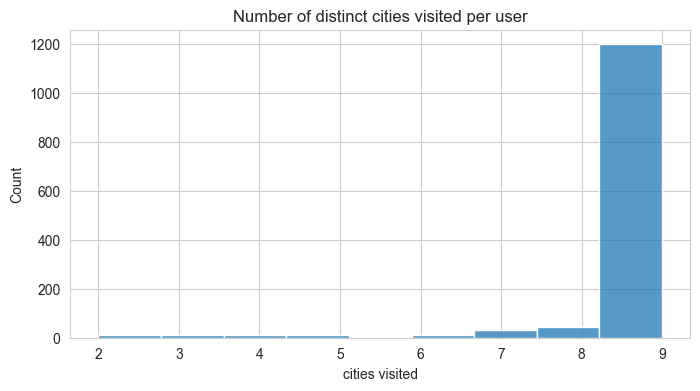

89.7% of users have visited all 9 cities in the network.


In [2]:
visited, place_stats = build_recommender_tables(flights, hotels, users)
cities_visited_per_user = visited.groupby('userCode')['to'].nunique()

plt.figure(figsize=(8, 4))
sns.histplot(cities_visited_per_user, bins=9)
plt.title('Number of distinct cities visited per user')
plt.xlabel('cities visited')
plt.show()

print(f"{(cities_visited_per_user == 9).mean():.1%} of users have visited all 9 cities in the network.")

That confirms it: a large share of users have already visited every city, so "recommend a city they haven't tried" runs dry for a lot of the user base — hence the fallback logic.

## 2. Price-band matching

In [3]:
artifacts = build_recommender_artifacts(flights, hotels, users)
print('Price band cutoffs (quartiles of hotel price):', [round(b, 2) for b in artifacts['price_bins']])
artifacts['place_stats']

Price band cutoffs (quartiles of hotel price): [np.float64(165.99), np.float64(242.88), np.float64(263.41)]


,place,avg_price,n_bookings,avg_days,popularity,price_band
0,Aracaju (SE),208.04,4205,2.491558,37224,1
1,Brasilia (DF),247.62,4437,2.486365,30779,2
2,Campo Grande (MS),60.39,4333,2.495500,34748,0
3,Florianopolis (SC),313.02,3330,2.483183,57317,3
4,Natal (RN),242.88,4829,2.499068,23796,1
5,Recife (PE),312.83,4467,2.520931,30480,3
6,Rio de Janeiro (RJ),165.99,5029,2.485981,16815,0
7,Salvador (BH),263.41,5094,2.516490,17104,2
8,Sao Paulo (SP),139.10,4828,2.511599,23625,0


## 3. Example recommendations

In [4]:
for uc in [0, 5, 42, 100]:
    row = users[users['code'] == uc].iloc[0]
    n_cities = cities_visited_per_user.get(uc, 0)
    print(f"User {uc} — {row['name']} ({row['company']}) — visited {n_cities}/9 cities")
    for r in recommend_for_user(uc, artifacts, n=3):
        print(f"   -> {r['place']:22s} | hotel: {r['suggested_hotel']:10s} \${r['suggested_hotel_price']:>7.2f}/night | {r['reason']}")
    print()

User 0 — Roy Braun (4You) — visited 9/9 cities
   -> Campo Grande (MS)      | hotel: Hotel BW   \$  60.39/night | worth revisiting
   -> Florianopolis (SC)     | hotel: Hotel A    \$ 313.02/night | worth revisiting
   -> Rio de Janeiro (RJ)    | hotel: Hotel CB   \$ 165.99/night | worth revisiting

User 5 — Trina Thomas (4You) — visited 9/9 cities
   -> Florianopolis (SC)     | hotel: Hotel A    \$ 313.02/night | worth revisiting
   -> Natal (RN)             | hotel: Hotel BD   \$ 242.88/night | worth revisiting
   -> Rio de Janeiro (RJ)    | hotel: Hotel CB   \$ 165.99/night | worth revisiting

User 42 — Robert Collins (4You) — visited 4/9 cities
   -> Campo Grande (MS)      | hotel: Hotel BW   \$  60.39/night | new destination match
   -> Recife (PE)            | hotel: Hotel AU   \$ 312.83/night | new destination match
   -> Sao Paulo (SP)         | hotel: Hotel AF   \$ 139.10/night | new destination match

User 100 — Carla Puskar (4You) — visited 9/9 cities
   -> Campo Grande (MS) 

<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
C:\Users\sanas\AppData\Local\Temp\ipykernel_10276\3342356991.py:6: SyntaxWarning: invalid escape sequence '\$'
  print(f"   -> {r['place']:22s} | hotel: {r['suggested_hotel']:10s} \${r['suggested_hotel_price']:>7.2f}/night | {r['reason']}")


## 4. Recommendation reason mix across the user base

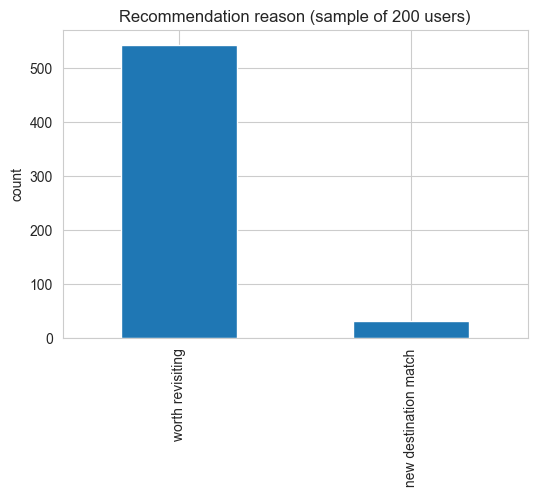

In [5]:
import collections
reason_counts = collections.Counter()
for uc in users['code'].sample(200, random_state=42):
    for r in recommend_for_user(uc, artifacts, n=3):
        reason_counts[r['reason']] += 1

pd.Series(reason_counts).plot(kind='bar', figsize=(6, 4), title='Recommendation reason (sample of 200 users)')
plt.ylabel('count')
plt.show()

## 5. Saved artifacts

`models/recommender_artifacts.joblib` bundles the visit table, place-level
popularity/price stats, user price-band lookup, and per-place cheapest hotel
lookup — everything `recommend_for_user()` needs at serving time. This is
loaded directly in `main.py`'s "Recommender" page with a user-code selector.